# Dolomite in NaCl — aqueous speciation (fixed pCO₂, pH from mass balance) and net surface charge

This notebook computes the aqueous speciation of the dolomite titration solutions from **published
thermodynamic constants only** (TOUGHREACT / EQ3-6: Plummer & Busenberg 1982; Nordstrom et al. 1990;
Wolery 1992), and from that speciation the net surface charge of dolomite (Pokrovsky et al., 1999).
The recipe:

* the carbonate system is **open** — CO₂(aq) is held at a fixed activity set by atmospheric pCO₂,
* **pH is calculated from the proton mass balance**, not read from the electrode,
* the free-ion **H⁺ starts from a neutral guess (10⁻⁷)** and is solved from the proton condition,
* Davies activity coefficients (b = 0.5), neutral species γ₀ = 1,
* no surface complexation model.

Every equation is written out below: the reactions, the law of mass action for each species, the
element mass balances, and the proton condition that fixes pH. The net surface charge
(Pokrovsky Eqn 1) is computed at the calculated pH, and the result is **compared** with a Visual
MINTEQ run of the same solutions — comparison only, no values are taken from the software.

## 1. Reactions and equilibrium constants (25 °C, log₁₀K)

Written as dissociations (complex on the left). All constants are **published values** from the
TOUGHREACT / EQ3-6 thermodynamic database (Plummer & Busenberg 1982; Nordstrom et al. 1990;
Wolery 1992). None is taken from the Visual MINTEQ output.

**Water and carbonate**

| reaction | log K |
|----------|-------|
| H₂O = H⁺ + OH⁻ | −13.995 |
| CO₂(aq) + H₂O = H⁺ + HCO₃⁻ | −6.345 |
| HCO₃⁻ = H⁺ + CO₃²⁻ | −10.329 |
| CO₂(g) = CO₂(aq), log K_H = −1.469 → {CO₂(aq)} = 10⁻¹·⁴⁶⁹·pCO₂, pCO₂ = 10⁻³·⁵ atm | (fixed) |

**Calcium / magnesium / sodium complexes** (dissociation, log K)

| reaction | log K | reaction | log K |
|----------|-------|----------|-------|
| CaCl⁺ = Ca²⁺ + Cl⁻ | 0.696 | MgCl⁺ = Mg²⁺ + Cl⁻ | 0.135 |
| CaCO₃(aq) + H⁺ = Ca²⁺ + HCO₃⁻ | 7.002 | MgCO₃(aq) + H⁺ = Mg²⁺ + HCO₃⁻ | 7.350 |
| CaHCO₃⁺ = Ca²⁺ + HCO₃⁻ | −1.047 | MgHCO₃⁺ = Mg²⁺ + HCO₃⁻ | −1.036 |
| CaOH⁺ + H⁺ = Ca²⁺ + H₂O | 12.850 | MgOH⁺ + H⁺ = Mg²⁺ + H₂O | 11.785 |
| NaCl(aq) = Na⁺ + Cl⁻ | 0.777 | NaCO₃⁻ + H⁺ = Na⁺ + HCO₃⁻ | 9.815 |
| NaHCO₃(aq) = Na⁺ + HCO₃⁻ | −0.154 | NaOH(aq) + H⁺ = Na⁺ + H₂O | 14.180 |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import brentq

# log10 K of each dissociation — published TOUGHREACT / EQ3-6 constants
# (Plummer & Busenberg 1982; Nordstrom et al. 1990; Wolery 1992). Nothing taken from MINTEQ.
lk = dict(co2=-6.345, co3=10.329, oh=13.995,
          cacl=0.696, caco3=7.002, cahco3=-1.047, caoh=12.850,
          mgcl=0.135, mgco3=7.350, mghco3=-1.036, mgoh=11.785,
          nacl=0.777, naco3=9.815, nahco3=-0.154, naoh=14.180)

# open system: {CO2(aq)} fixed by atmospheric pCO2 and Henry's law
pCO2  = 10**-3.5                 # atm (atmospheric)
logKH = -1.469                   # CO2(g) = CO2(aq), TOUGHREACT / EQ3-6 (25 C)
aCO2  = 10**logKH * pCO2         # fixed {CO2(aq)} activity
A_DAVIES = 0.509
DAVIES_B = 0.5                   # Davies salting term
MM = dict(Ca=40.078, Mg=24.305, Na=22.99, Cl=35.45, CO3=60.008, HCO3=61.016)

# surface area of dolomite per litre of reactor C  (Pokrovsky Eqn 1)
St = 0.76 * 60.0      # 0.76 m2/g * 60 g/L = 45.6 m2/L

## 2. Activity coefficients (Davies, b = 0.5)

$$\log\gamma_z=-A\,z^2\!\left(\frac{\sqrt I}{1+\sqrt I}-b\,I\right),\qquad
\gamma_0=1\ \text{(neutral species)}$$

with A = 0.509 and the Davies salting term b = 0.5. Neutral aqueous species take unit activity
coefficient (γ₀ = 1).

In [2]:
def gammas(I):
    if I <= 0:
        return 1.0, 1.0, 1.0
    f = -A_DAVIES * (np.sqrt(I)/(1+np.sqrt(I)) - DAVIES_B*I)
    return 10**f, 10**(4*f), 1.0     # gamma1 (z=1), gamma2 (z=2), gamma0 (neutral) = 1

## 3. Law of mass action and the element mass balances

With `aH = {H⁺}` and the fixed `aCO2`, the carbonate activities are

$$\{HCO_3^-\}=10^{-6.345}\,\frac{\{CO_2\}}{\{H^+\}},\quad
\{CO_3^{2-}\}=\frac{\{HCO_3^-\}}{10^{10.329}\{H^+\}},\quad
\{OH^-\}=\frac{10^{-13.995}}{\{H^+\}}$$

Each complex activity is its mass-action law, e.g. $\{CaHCO_3^+\}=10^{1.047}\{Ca^{2+}\}\{HCO_3^-\}$,
$\{CaCl^+\}=\{Ca^{2+}\}\{Cl^-\}/10^{0.696}$, $\{CaOH^+\}=\{Ca^{2+}\}/(10^{12.850}\{H^+\})$.

The four **mass balances** (free ion = total − everything it is bound into; no surface terms) close the
system for the free-ion activities `aCa, aMg, aNa, aCl`:

```
Ca_T = [Ca²⁺] + [CaCl⁺] + [CaCO₃] + [CaHCO₃⁺] + [CaOH⁺]
Mg_T = [Mg²⁺] + [MgCl⁺] + [MgCO₃] + [MgHCO₃⁺] + [MgOH⁺]
Na_T = [Na⁺]  + [NaCl]   + [NaCO₃⁻] + [NaHCO₃] + [NaOH]
Cl_T = [Cl⁻]  + [CaCl⁺] + [MgCl⁺] + [NaCl]
```

Because every metal species is proportional to its free-ion activity, each metal total gives
`aMe = Me_T / d_Me` with `d_Me` the bracketed sum; `aCl` follows from the Cl balance. The two are
iterated (and the ionic strength around them) to convergence.

In [3]:
def speciate(pH, CaT, MgT, NaT, ClT):
    """Full speciation at a fixed pH and fixed pCO2 (Davies activities)."""
    aH = 10**(-pH)
    I  = 0.5*(NaT + ClT + 4*CaT + 4*MgT)
    aCa = aMg = aNa = aCl = 0.0
    for _ in range(200):
        g1, g2, g0 = gammas(I)
        aHCO3 = 10**lk['co2']*aCO2/aH          # {HCO3-}
        aCO3  = aHCO3/(10**lk['co3']*aH)       # {CO3^2-}
        aOH   = 10**(-lk['oh'])/aH             # {OH-}
        cH, cOH, cHCO3, cCO3, cCO2 = aH/g1, aOH/g1, aHCO3/g1, aCO3/g2, aCO2/g0
        if aCl == 0:
            aCa, aMg, aNa, aCl = g2*CaT, g2*MgT, g1*NaT, g1*ClT
        for _ in range(100):
            dCa = (1/g2 + aCl/(g1*10**lk['cacl']) + aHCO3/(g0*aH*10**lk['caco3'])
                   + aHCO3*10**(-lk['cahco3'])/g1 + 1/(g1*aH*10**lk['caoh']))
            dMg = (1/g2 + aCl/(g1*10**lk['mgcl']) + aHCO3/(g0*aH*10**lk['mgco3'])
                   + aHCO3*10**(-lk['mghco3'])/g1 + 1/(g1*aH*10**lk['mgoh']))
            dNa = (1/g1 + aHCO3/(g1*aH*10**lk['naco3']) + aHCO3*10**(-lk['nahco3'])/g0
                   + aCl/(g0*10**lk['nacl']) + 1/(g0*aH*10**lk['naoh']))
            aCa, aMg, aNa = CaT/dCa, MgT/dMg, NaT/dNa
            dCl = (1/g1 + aCa/(g1*10**lk['cacl']) + aMg/(g1*10**lk['mgcl']) + aNa/(g0*10**lk['nacl']))
            aCl_new = ClT/dCl
            if abs(aCl_new-aCl) < 1e-12: aCl = aCl_new; break
            aCl = aCl_new
        # complex concentrations
        cCaCl  = aCa*aCl/(g1*10**lk['cacl']);   cCaCO3 = aCa*aHCO3/(g0*aH*10**lk['caco3'])
        cCaHCO3= aCa*aHCO3*10**(-lk['cahco3'])/g1; cCaOH = aCa/(g1*aH*10**lk['caoh'])
        cMgCl  = aMg*aCl/(g1*10**lk['mgcl']);   cMgCO3 = aMg*aHCO3/(g0*aH*10**lk['mgco3'])
        cMgHCO3= aMg*aHCO3*10**(-lk['mghco3'])/g1; cMgOH = aMg/(g1*aH*10**lk['mgoh'])
        cNaCl  = aNa*aCl/(g0*10**lk['nacl']);   cNaCO3 = aNa*aHCO3/(g1*aH*10**lk['naco3'])
        cNaHCO3= aNa*aHCO3*10**(-lk['nahco3'])/g0; cNaOH = aNa/(g0*aH*10**lk['naoh'])
        cCa, cMg, cNa, cCl = aCa/g2, aMg/g2, aNa/g1, aCl/g1
        Inew = 0.5*(cNa+cCl+cH+cOH+4*cCa+4*cMg+4*cCO3+cHCO3+cCaCl+cCaHCO3+cCaOH
                    +cMgCl+cMgHCO3+cMgOH+cNaCO3)
        if abs(Inew-I) < 1e-10: I = Inew; break
        I = 0.5*I + 0.5*Inew
    return dict(pH=pH, I=I, H=cH, OH=cOH, CO2=cCO2, HCO3=cHCO3, CO3=cCO3,
                Ca=cCa, CaCl=cCaCl, CaCO3=cCaCO3, CaHCO3=cCaHCO3, CaOH=cCaOH,
                Mg=cMg, MgCl=cMgCl, MgCO3=cMgCO3, MgHCO3=cMgHCO3, MgOH=cMgOH,
                Na=cNa, NaCl=cNaCl, NaCO3=cNaCO3, NaHCO3=cNaHCO3, NaOH=cNaOH, Cl=cCl)

## 4. pH from the mass balance (proton condition, fixed pCO₂)

With CO₂ as the fixed reference, the proton condition (total excess H⁺ relative to CO₂/H₂O and the
metal/Na components) is

$$P(\text{pH})=[H^+]-[OH^-]-[HCO_3^-]-2[CO_3^{2-}]-[NaHCO_3]-2[NaCO_3^-]-[CaHCO_3^+]-2[CaCO_3]-[CaOH^+]-[MgHCO_3^+]-2[MgCO_3]-[MgOH^+]-[NaOH]$$

MINTEQ sets the total H⁺ from the entered carbonate: the total CO₃²⁻ component `C_CO3` (the measured
CO₃²⁻) contributes `−2·C_CO3`. So pH is the root of

$$P(\text{pH})=-2\,C_{CO3}.$$

The free H⁺ starts from the neutral guess 10⁻⁷ (bracketed for the root find). Ca²⁺, Mg²⁺, Na⁺ and Cl⁻
carry no proton, so — unlike a charge balance — dissolved Ca/Mg do not drag the pH the wrong way.

**Important — pH is obtained from this proton (hydrogen) mass balance, not from a charge balance.** Forcing the aqueous charge sum $\sum_k z_k[k]=0$ would set to zero the very quantity that Pokrovsky Eqn 1 measures, so the residual charge is left free: pH is fixed by the proton and carbonate balances, while Ca²⁺, Mg²⁺, Na⁺ and Cl⁻ (no proton) do not enter it.

In [4]:
def proton_condition(s):
    return (s['H'] - s['OH'] - s['HCO3'] - 2*s['CO3']
            - s['NaHCO3'] - 2*s['NaCO3'] - s['CaHCO3'] - 2*s['CaCO3'] - s['CaOH']
            - s['MgHCO3'] - 2*s['MgCO3'] - s['MgOH'] - s['NaOH'])

def solve_pH(CaT, MgT, NaT, ClT, C_CO3):
    f = lambda pH: proton_condition(speciate(pH, CaT, MgT, NaT, ClT)) + 2*C_CO3
    return brentq(f, 3.0, 11.5, xtol=1e-7)   # H+ from a neutral (1e-7) bracket

## 5. Measured data (run-aligned)

Columns: measured pH (reference only), Cl, Na, Ca, Mg, CO₃, HCO₃ (mg/L). `C_CO3` (the total CO₃²⁻
component MINTEQ uses to fix the pH) is the measured CO₃ column.

In [5]:
A = pd.DataFrame({'run':range(1,10),'pH':[8.9,8.8,8.9,9.0,9.0,8.8,8.8,9.0,8.9],
 'Cl':[48942,39648,42883,38612,33835,36206,32751,30515,32807],
 'Na':[27749.8,23604.3,34199.3,29672.0,24947.5,26775.3,24657.7,21705.0,23506.8],
 'Ca':[29.4,30.7,28.3,28.2,30.1,35.0,31.0,30.6,35.7],
 'Mg':[43.3,42.7,41.2,41.6,43.8,49.5,46.6,45.1,45.0],
 'CO3':[27.9,23.4,32.1,31.7,30.4,23.5,20.8,35.0,22.9],'HCO3':[119.8,127.8,107.8,116.1,109.7,125.5,131.5,121.0,128.3]})
B = pd.DataFrame({'run':range(1,10),'pH':[2.4,2.1,2.1,1.8,5.5,10.5,10.6,10.6,10.8],
 'Cl':[16937,17017,16827,16777,16838,16879,16854,16829,17022],
 'Na':[53900,32927,23180,24113,23718,21836,21302,21073,23484],
 'Ca':[0]*9,'Mg':[0]*9,'CO3':[0,0,0,0,0,48.0,46.6,55.0,80.1],'HCO3':[0]*9})
C = pd.DataFrame({'run':range(1,10),'pH':[7.5,7.5,7.2,7.0,8.8,9.8,10.2,10.2,10.6],
 'Cl':[24901,32258,36300,26800,24244,23699,21815,24118,22678],
 'Na':[19593.1,23296.4,25729.3,16953.4,16466.5,16183.2,14759.0,16450.8,15393.8],
 'Ca':[398.9,560.6,755.1,1325.3,37.2,15.6,16.3,17.0,9.8],
 'Mg':[114.2,145.9,180.4,233.9,24.4,13.6,4.4,3.6,1.0],
 'CO3':[0,0,0,0,18.2,92.8,120.2,134.0,136.4],'HCO3':[407.6,413.3,250.1,527.5,106.1,7.2,0,0,0]})

def totals(r):
    return (r['Ca']/MM['Ca']/1e3, r['Mg']/MM['Mg']/1e3, r['Na']/MM['Na']/1e3,
            r['Cl']/MM['Cl']/1e3, r['CO3']/MM['CO3']/1e3)   # Ca,Mg,Na,Cl, C_CO3

def run_all(df):
    out=[]
    for _,r in df.iterrows():
        CaT,MgT,NaT,ClT,Cc = totals(r)
        pH = solve_pH(CaT,MgT,NaT,ClT,Cc)
        s = speciate(pH,CaT,MgT,NaT,ClT); s['run']=int(r['run']); s['pH_meas']=r['pH']
        out.append(s)
    return out
resA, resB, resC = run_all(A), run_all(B), run_all(C)

## 6. Calculated pH compared with Visual MINTEQ

The calculated pH is placed side by side with a Visual MINTEQ run of the same solutions, as an
external comparison only. The one row that differs most, vessel B run 6, is because the MINTEQ run for
it carried no carbonate (its RUN5/RUN6 columns are identical); the model value is what a B run with
48 mg/L CO₃ gives.

In [6]:
minteq = {'A':[8.03,7.957,8.052,8.054,8.045,7.942,7.894,8.104,7.936],
          'B':[5.476,5.536,5.56,5.558,5.559,5.559,8.196,8.259,8.387],
          'C':[5.561,5.551,5.543,5.556,7.85,8.482,8.579,8.611,8.622]}
for tag,res in [('A',resA),('B',resB),('C',resC)]:
    df = pd.DataFrame({'pH calc':[round(s['pH'],3) for s in res],
                       'pH MINTEQ':minteq[tag],
                       'I calc':[round(s['I'],3) for s in res]})
    df.index=[f'run {i+1}' for i in range(9)]; df.index.name=f'Vessel {tag}'
    print(df.to_string()); print()

          pH calc  pH MINTEQ  I calc
Vessel A                            
run 1       7.883      8.030   1.086
run 2       7.840      7.957   0.938
run 3       7.879      8.052   1.122
run 4       7.911      8.054   1.019
run 5       7.934      8.045   0.901
run 6       7.808      7.942   0.953
run 7       7.774      7.894   0.885
run 8       8.022      8.104   0.813
run 9       7.826      7.936   0.867

          pH calc  pH MINTEQ  I calc
Vessel B                            
run 1       5.309      5.476   1.260
run 2       5.439      5.536   0.875
run 3       5.500      5.560   0.689
run 4       5.494      5.558   0.706
run 5       5.497      5.559   0.700
run 6       8.150      5.559   0.664
run 7       8.143      8.196   0.654
run 8       8.215      8.259   0.649
run 9       8.351      8.387   0.697

          pH calc  pH MINTEQ  I calc
Vessel C                            
run 1       5.507      5.561   0.736
run 2       5.474      5.551   0.885
run 3       5.451      5.543   0.973

## 7. Full speciation at the calculated pH (mol/L) — compare with the MINTEQ sheet

In [7]:
order = ['H','OH','CO2','HCO3','CO3','Ca','CaCl','CaCO3','CaHCO3','CaOH',
         'Mg','MgCl','MgCO3','MgHCO3','MgOH','Na','NaCl','NaCO3','NaHCO3','NaOH','Cl']
def spec_table(res, tag):
    cols={f'run {s["run"]}':[s[k] for k in order] for s in res}
    df=pd.DataFrame(cols, index=order); df.index.name=f'Vessel {tag} (mol/L)'
    return df
for tag,res in [('A',resA),('B',resB),('C',resC)]:
    print(f'--- Vessel {tag} ---')
    print(spec_table(res,tag).to_string(float_format=lambda x: f'{x:.3e}')); print()

--- Vessel A ---
                     run 1     run 2     run 3     run 4     run 5     run 6     run 7     run 8     run 9
Vessel A (mol/L)                                                                                          
H                1.259e-08 1.484e-08 1.252e-08 1.217e-08 1.215e-08 1.589e-08 1.769e-08 1.028e-08 1.581e-08
OH               7.441e-07 7.195e-07 7.242e-07 8.174e-07 9.068e-07 6.630e-07 6.310e-07 1.152e-06 7.168e-07
CO2              1.074e-05 1.074e-05 1.074e-05 1.074e-05 1.074e-05 1.074e-05 1.074e-05 1.074e-05 1.074e-05
HCO3             3.570e-04 3.452e-04 3.474e-04 3.921e-04 4.350e-04 3.181e-04 3.027e-04 5.528e-04 3.439e-04
CO3              1.140e-06 1.214e-06 1.046e-06 1.460e-06 1.992e-06 1.018e-06 9.770e-07 3.459e-06 1.280e-06
Ca               5.719e-04 6.477e-04 5.633e-04 5.871e-04 6.542e-04 7.477e-04 6.800e-04 6.811e-04 7.846e-04
CaCl             1.571e-04 1.147e-04 1.382e-04 1.119e-04 9.224e-05 1.217e-04 9.066e-05 7.667e-05 1.024e-04
CaCO3            1.8

## 8. Net surface charge — Pokrovsky Eqn 1

The reference is the **conservative A+B mixture, speciated as one solution**. The A and B analytical
totals are combined by conserving moles (equal volumes here), and that mixture is speciated at its own
calculated pH to give q₀. With q = Σ z_k[k] over the reactive species (free Na⁺, Cl⁻ cancel):

$$C_{j,0}=\frac{C_{j,A}V_A+C_{j,B}V_B}{V_A+V_B},\qquad
q_0=q\big(\mathrm{speciate}(C_{\cdot,0})\big),\qquad
\sigma_T=\frac{q_0-q_C}{S}.$$

This replaces the earlier ½(q_A+q_B) average, which is not identical because speciation is nonlinear.

In [8]:
VA = VB = 100.0            # mL, equal mixing volumes (Parameters sheet)

def qcharge(s):                        # q = sum z_k [k] over the reactive ions
    q_H    = s['H'] - s['OH']
    q_carb = -s['HCO3'] - 2*s['CO3'] - s['NaCO3']
    q_Ca   = 2*s['Ca'] + s['CaCl'] + s['CaHCO3'] + s['CaOH']
    q_Mg   = 2*s['Mg'] + s['MgCl'] + s['MgHCO3'] + s['MgOH']
    return q_H + q_carb + q_Ca + q_Mg   # free Na+, Cl- omitted (they cancel)

def mix_totals(rA, rB):                 # conserve moles into the A+B mixture
    ta, tb = totals(rA), totals(rB)     # each: (Ca, Mg, Na, Cl, C_CO3) in mol/L
    return tuple((a*VA + b*VB)/(VA+VB) for a, b in zip(ta, tb))

rows = []
for i in range(9):
    CaT0, MgT0, NaT0, ClT0, Cc0 = mix_totals(A.iloc[i], B.iloc[i])   # mixed totals
    pH0 = solve_pH(CaT0, MgT0, NaT0, ClT0, Cc0)                      # mixture's own pH
    q0  = qcharge(speciate(pH0, CaT0, MgT0, NaT0, ClT0))            # reference (speciated mix)
    qf  = qcharge(resC[i])                                          # reacted vessel C
    sig = (q0 - qf) / St                                            # mol / m2
    rows.append({'run': i+1, 'pH_mix': round(pH0, 3), 'pH_C': round(resC[i]['pH'], 3),
                 'sigma_T (mol/m2)': sig, 'sigma_T (mmol/m2)': sig*1e3})
surf = pd.DataFrame(rows).set_index('run')
print(surf.to_string(float_format=lambda x: f'{x:.4g}'))

     pH_mix  pH_C  sigma_T (mol/m2)  sigma_T (mmol/m2)
run                                                   
1     7.457 5.507        -0.0005592            -0.5592
2     7.491 5.474        -0.0007532            -0.7532
3     7.625 5.451        -0.0009892            -0.9892
4     7.635 5.499         -0.001716             -1.716
5     7.639 7.792        -2.571e-05           -0.02571
6     8.006 8.482          4.72e-05             0.0472
7     7.992   8.6         7.232e-05            0.07232
8     8.129  8.63         7.046e-05            0.07046
9     8.167 8.648         8.602e-05            0.08602


## 8b. Net surface charge vs pH (plot)

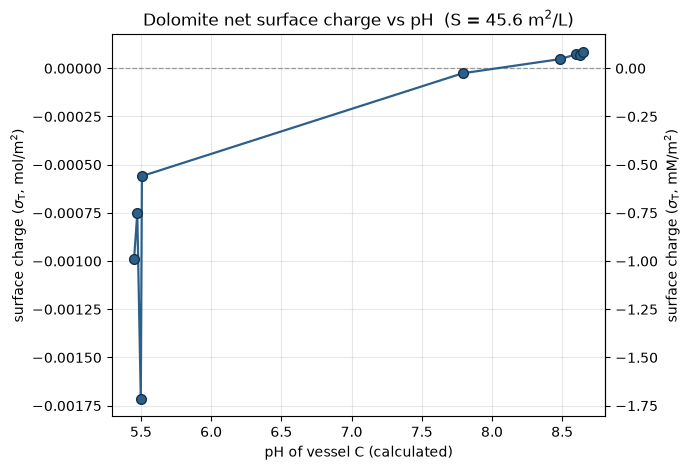

In [9]:
# --- plot: net surface charge vs pH (line, ordered by pH; no point labels) ---
sp = surf.sort_values('pH_C')
fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.axhline(0, color='0.6', lw=0.9, ls='--')
ax.plot(sp['pH_C'], sp['sigma_T (mol/m2)'], '-o', color='#2c5f8a',
        markeredgecolor='#12314a', lw=1.6, ms=7, zorder=3)
ax.set_xlabel('pH of vessel C (calculated)')
ax.set_ylabel(r'surface charge ($\sigma_\mathrm{T}$, mol/m$^2$)')
secax = ax.secondary_yaxis('right', functions=(lambda v: v*1e3, lambda v: v/1e3))
secax.set_ylabel(r'surface charge ($\sigma_\mathrm{T}$, mM/m$^2$)')
ax.set_title('Dolomite net surface charge vs pH  (S = 45.6 m$^2$/L)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9. Comparison — surface charge from the Visual MINTEQ speciation

External check only. Here q₀ is taken as ½(q_A+q_B) on **both** sides, like-for-like with the MINTEQ
sheet (which averaged the two vessels). The reported σ_T above instead uses the speciated A+B mixture.
The published-constant model and the MINTEQ comparison agree closely on the base runs; the acid runs
differ by roughly 20%, the expected offset between two independent constant sets.

In [10]:
# q = Sum z_k [k] computed from the MINTEQ output sheet (reactive species; Na+, Cl- cancel)
qA_minteq = [0.00243018,0.00270948,0.002316,0.00240532,0.0027143,0.00330188,0.00316131,0.00277309,0.00319026]
qB_minteq = [1.54e-06,1.05e-06,7.9e-07,8.2e-07,8e-07,8e-07,-0.00117935,-0.00138748,-0.0019341]
qC_minteq = [0.0222037,0.02836853,0.03607385,0.06418259,0.00242157,-0.00099972,-0.00224561,-0.00255847,-0.00309556]

chk = []
for i in range(9):
    sigma_minteq = (0.5*(qA_minteq[i]+qB_minteq[i]) - qC_minteq[i])/St*1e3
    sigma_model  = (0.5*(qcharge(resA[i])+qcharge(resB[i])) - qcharge(resC[i]))/St*1e3
    chk.append({'run':i+1, 'sigma_T model':sigma_model,
                'sigma_T from MINTEQ':sigma_minteq})
print(pd.DataFrame(chk).set_index('run').to_string(float_format=lambda x: f'{x:.4g}'))

     sigma_T model  sigma_T from MINTEQ
run                                    
1          -0.5627              -0.4603
2          -0.7558              -0.5924
3           -0.992              -0.7657
4           -1.718               -1.381
5         -0.02768             -0.02333
6          0.04378              0.05814
7          0.06978              0.07098
8           0.0687               0.0713
9          0.08385              0.08166


## Notes

1. **Published constants only.** Every equilibrium constant is a published TOUGHREACT / EQ3-6 value
   (Plummer & Busenberg 1982; Nordstrom et al. 1990; Wolery 1992). Nothing is taken from the software;
   the Visual MINTEQ output is used for comparison only.
2. **Fixed pCO₂ + pH from mass balance:** {CO₂(aq)} is fixed by atmospheric pCO₂ (10⁻³·⁵ atm) and
   Henry's law, and pH is the root of the proton condition `P(pH) = −2·C_CO3`, with the free H⁺ started
   from 10⁻⁷. Ca²⁺, Mg²⁺, Na⁺, Cl⁻ carry no proton, so dissolved Ca/Mg do not push the pH the wrong
   way — vessel C falls with acid and rises with base.
3. **Inputs.** For A and C the totals are Ca, Mg, Na, Cl and CO₃; for B they are Na, Cl and CO₃; the
   free H⁺ starts from 10⁻⁷.
4. **No surface complexation model.** The surface charge is the aqueous charge-sum difference of
   Pokrovsky Eqn 1 (σ_T = (½(q_A+q_B) − q_C)/S) at the calculated pH, with S = 45.6 m²/L.
5. Vessel B run 6 differs from the MINTEQ comparison because that MINTEQ run carried no carbonate.